In [175]:
import pandas as pd
import numpy as np
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor  
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import time 

In [176]:
#reading the  data
clean_df = pd.read_csv('./processed-data/clean-listings.csv')


In [177]:
# some feature engeneering 
#nDf['neighbourhood_cleansed'].unique()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# nDf['neighbourhood_cleansed_encoded'] = le.fit_transform(nDf['neighbourhood_cleansed'])  # IMPORTANT CHATGPT SAYS THIS MAY BE PROBLEMATIC FOR LINEAR REG !!!
# nDf['neighbourhood_cleansed_encoded'].dtype
#clean_df = pd.get_dummies(clean_df, columns=['neighbourhood_cleansed'], prefix='neigh')
#clean_df = clean_df.astype({col: 'Int64' for col in clean_df.columns if clean_df[col].dtype == 'bool'})


In [178]:
clean_df.dtypes

listing_id                       int64
latitude                       float64
longitude                      float64
accommodates                   float64
bathrooms                      float64
bedrooms                       float64
beds                           float64
price                          float64
minimum_nights                 float64
maximum_nights                 float64
minimum_minimum_nights         float64
maximum_minimum_nights         float64
minimum_maximum_nights         float64
maximum_maximum_nights         float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
availability_30                float64
availability_60                float64
availability_90                float64
availability_365               float64
number_of_reviews              float64
number_of_reviews_ltm          float64
number_of_reviews_l30d         float64
number_of_reviews_ly           float64
estimated_occupancy_l365d      float64
estimated_revenue_l365d  

In [179]:
#nDf[["comments","listing_id","price","description"]].head(25)

In [180]:
#dropping all id coloumns (just for testing)
clean_df = clean_df.loc[:, ~clean_df.columns.str.contains('id', case=False)]
clean_df = clean_df.select_dtypes(include=['int', 'float64'])

In [181]:

columns_to_drop = ["minimum_minimum_nights" , "maximum_minimum_nights" , "minimum_maximum_nights" , "maximum_maximum_nights"] #, "estimated_revenue_l365d" ]
clean_df = clean_df.drop(columns=columns_to_drop)
clean_df = clean_df.drop_duplicates()
clean_df.dtypes


latitude                       float64
longitude                      float64
accommodates                   float64
bathrooms                      float64
bedrooms                       float64
beds                           float64
price                          float64
minimum_nights                 float64
maximum_nights                 float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
availability_30                float64
availability_60                float64
availability_90                float64
availability_365               float64
number_of_reviews              float64
number_of_reviews_ltm          float64
number_of_reviews_l30d         float64
number_of_reviews_ly           float64
estimated_occupancy_l365d      float64
estimated_revenue_l365d        float64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communicati

In [182]:
correlations = clean_df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlations)

price                          1.000000
accommodates                   0.519946
bathrooms                      0.483732
beds                           0.480714
bedrooms                       0.398584
estimated_revenue_l365d        0.348026
latitude                       0.152106
review_scores_location         0.111490
longitude                      0.106249
review_scores_cleanliness      0.091751
availability_30                0.083563
availability_365               0.083264
review_scores_rating           0.074673
availability_60                0.062525
maximum_nights                 0.058760
review_scores_accuracy         0.050262
availability_90                0.047465
maximum_nights_avg_ntm         0.043593
review_scores_value            0.021195
review_scores_communication    0.014490
review_scores_checkin          0.004653
number_of_reviews_l30d         0.000140
reviews_per_month             -0.004379
number_of_reviews_ltm         -0.021888
number_of_reviews_ly          -0.022804


In [183]:
features = clean_df.drop(columns=['price'])  
targets = clean_df['price']


In [184]:

# features = features.drop(columns=[
#     'estimated_occupancy_l365d',
#     'reviews_per_month',
#     'number_of_reviews',
#     'number_of_reviews_ltm',
#     'number_of_reviews_l30d',
#     'number_of_reviews_ly',
#     'availability_eoy',
#     'availability_365'
# ])



In [185]:
features.dtypes

latitude                       float64
longitude                      float64
accommodates                   float64
bathrooms                      float64
bedrooms                       float64
beds                           float64
minimum_nights                 float64
maximum_nights                 float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
availability_30                float64
availability_60                float64
availability_90                float64
availability_365               float64
number_of_reviews              float64
number_of_reviews_ltm          float64
number_of_reviews_l30d         float64
number_of_reviews_ly           float64
estimated_occupancy_l365d      float64
estimated_revenue_l365d        float64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communication    float64
review_scores_location   

In [186]:
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=1)               

In [187]:
# random forest model
print("Training model...")

estimators_list = [200] ## no big diffrence
mse_scores = []

for n in estimators_list:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_scores.append(mse)
    print(f"n_estimators = {n} --> MSE: {mse:.2f}")

Training model...
n_estimators = 200 --> MSE: 5830.82


In [ ]:
features = features.reset_index(drop=True)
features.loc[50]
# what ? why are they normalized ? 

latitude                       0.350712
longitude                     -1.831826
accommodates                   0.261062
bathrooms                     -0.424489
bedrooms                       0.453092
beds                          -0.578410
minimum_nights                -0.606687
maximum_nights                 1.499776
minimum_nights_avg_ntm        -0.647340
maximum_nights_avg_ntm        -0.048069
availability_30                0.100281
availability_60                0.132636
availability_90                0.200204
availability_365              -1.443677
number_of_reviews              2.560213
number_of_reviews_ltm         -0.509254
number_of_reviews_l30d         0.969671
number_of_reviews_ly          -0.592123
estimated_occupancy_l365d     -0.772537
estimated_revenue_l365d       -0.581701
review_scores_rating          -0.103609
review_scores_accuracy         0.195153
review_scores_cleanliness      0.059134
review_scores_checkin          0.004856
review_scores_communication    0.079327


In [195]:
features = features.drop_duplicates()

In [197]:
features

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,...,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,0.997671,1.630331,-0.557323,-0.424489,-0.417334,-0.578410,0.250495,1.499776,0.208794,-0.048069,...,-0.358813,-0.302706,6.764686e-01,0.746515,6.271915e-01,0.499287,4.050737e-01,0.314223,0.729704,-9.355214e-01
1,-0.275907,-0.444005,-0.557323,-0.424489,-0.417334,-0.578410,-0.640975,-1.109800,-0.681586,-0.048069,...,-0.339112,-0.407732,2.084219e-01,0.332993,4.693977e-01,0.334476,1.517150e-01,-0.685425,0.404026,-6.752172e-01
2,-0.290895,-0.382939,0.261062,-0.424489,-1.287761,0.061387,-0.640975,0.503851,-0.681586,-0.048074,...,-0.457319,-0.281977,2.084219e-01,0.160693,3.116039e-01,0.202628,3.688796e-01,-0.788837,0.295467,-6.582409e-01
3,0.555184,-0.161970,-0.148131,-0.424489,-1.287761,-0.578410,2.376306,1.499776,2.332007,-0.048069,...,-0.930146,-0.663388,-1.289328e+00,-1.183252,-2.880124e-01,-0.951043,-3.069559e+00,0.831282,0.159768,-1.014744e+00
4,0.515217,-0.194077,-0.557323,-0.424489,-1.287761,-0.578410,0.353357,1.499776,0.304681,-0.048069,...,-0.930146,-0.663388,8.012811e-01,0.746515,1.222514e-01,0.499287,5.498500e-01,0.831282,0.512585,-1.020403e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3616,1.118745,0.913361,1.079447,0.426131,1.323519,0.701183,-0.572400,-0.416434,-0.616520,-0.048078,...,-0.930146,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16
3617,0.768934,0.334107,1.079447,1.276752,0.453092,0.701183,-0.709549,-0.416434,-0.750076,-0.048078,...,-0.930146,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16
3618,-0.627883,-0.785576,1.897832,-0.424489,1.323519,0.701183,-0.709549,-0.416434,-0.667888,-0.048078,...,-0.930146,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16
3619,0.859872,0.369572,1.488639,1.276752,2.193945,1.980777,-0.572400,-0.416434,-0.616520,-0.048078,...,-0.930146,-0.663388,2.771394e-15,0.000000,5.605961e-15,0.000000,3.214681e-15,0.000000,0.000000,-1.256503e-16


In [198]:
# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Show a few rows
print(comparison_df.head(20))

    Actual  Predicted
0    179.0    183.555
1    165.0    208.045
2    110.0    148.190
3    239.0    234.775
4    205.0    215.905
5     56.0     66.740
6    251.0    180.075
7    188.0    253.625
8    288.0    261.725
9    248.0    245.070
10    58.0     55.770
11   134.0    223.735
12   270.0    324.250
13   227.0    228.490
14   155.0    163.185
15   144.0    157.650
16   124.0    134.265
17   183.0    181.140
18   299.0    235.580
19   115.0    122.430


In [192]:
print(comparison_df[comparison_df['Actual'] != comparison_df['Predicted']].head(-20))

     Actual  Predicted
0     179.0    183.555
1     165.0    208.045
2     110.0    148.190
3     239.0    234.775
4     205.0    215.905
..      ...        ...
700   333.0    265.215
701   129.0    261.685
702   630.0    433.565
703    55.0     60.460
704   214.0    211.345

[705 rows x 2 columns]


In [ ]:
import shap

# Create a SHAP explainer for tree-based models
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer(X_train.sample(100))

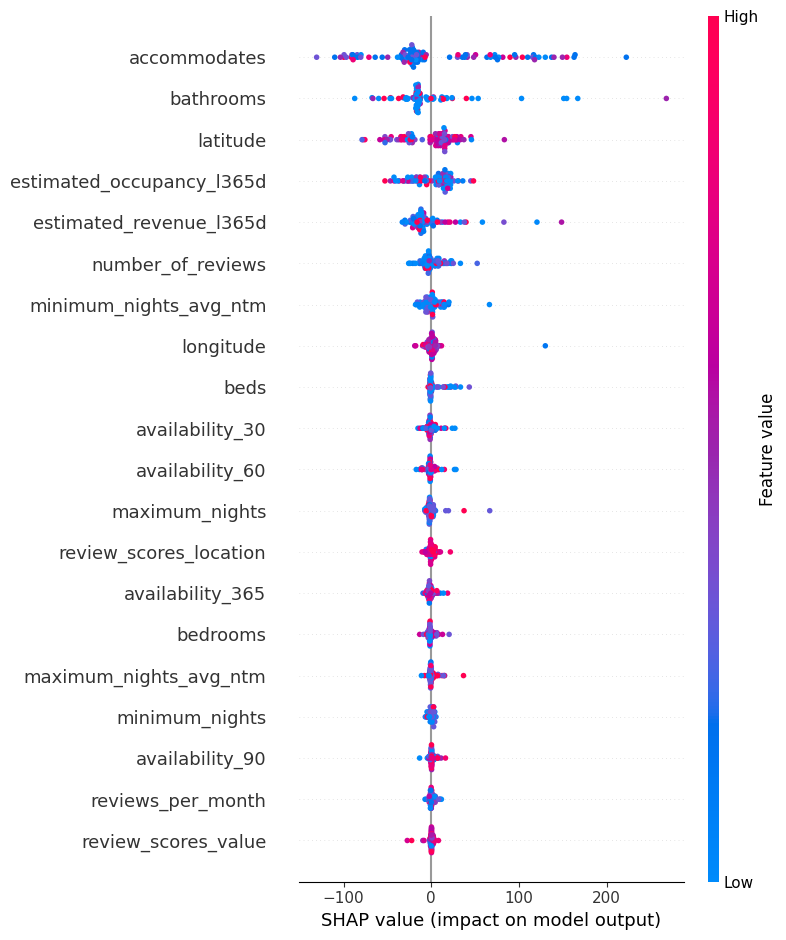

In [194]:
shap.summary_plot(shap_values, X_test.sample(100))